# 부동산 시셰 예측 졸업 프로젝트 연구 요약
## 연구 개요
### 연구 제목
다양한 형태의 데이터를 결합하여 아파트 시세 예측 모델 개발

### 연구 목적
#### 기존 연구 동향
- 모델 AB : 아파트 매매(A) + 위성 이미지(B) 데이터를 활용한 예측 모델
- 모델 AC : 아파트 매매(A) + 뉴스 감성 점수(C) 데이터를 활용한 예측 모델
- 세 가지 데이터(A, B, C)를 모두 결합한 연구 사례는 드묾

#### 본 연구의 목적
- 아파트 매매(A) + 위성 이미지(B) + 뉴스 감성 점수(C)데이터를 통합한 ABC 모델을 설계
- ABC모델이 AB, AC 모델보다 더 우수한 성능을 보이는지 검증이 목표

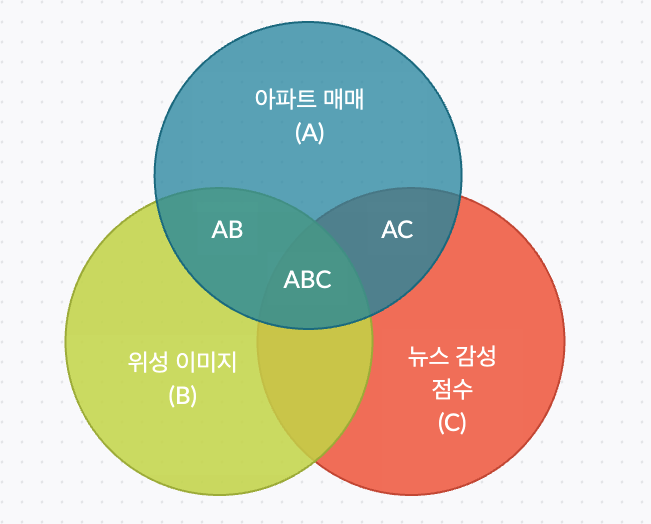

## 데이터 구성 및 수집 현황

수집되는 모든 데이터들의 기간은 아직 미정임.<br>
왜냐하면 언론사마다 마지막으로 올라온 기사 날짜가 달라 기사를 크롤링한 후 데이터 수집 기간을 정할 예정

### 1. 아파트 실거래 데이터
- 변수 : 위도, 경도, 전용면적, 층수, 거래년월, 거래금액 등등..
- 출처 : 국토교통부 실거래가 공개시스템 [https://rt.molit.go.kr/pt/xls/xls.do?mobileAt=]
- 연구에 사용될 변수선택과 전처리는 추후에 예정

### 2. 위성 이미지
- 수집 방법 : 위경도 기반 아파트 위치 주변 이미지 추출
    - 시계열 데이터와 병합할 예정이기 때문에 과거 위성지도를 제공하는 **Google Earth Engine** 사용 예정
        - 예) 2025년01월 아파트의 위성 이미지, 2025년02월 아파트의 위성 이미지... 이런식으로 추출 예정
    - ResNet-50을 통해 이미지 피처를 추출 예정
    - 증강 : RandomRotation, ColorJitter, GAN등 이미지 증강 고려

### 3. 감성 점수 데이터
- 수집 언론사 :
    - 조선일보
    - 동아일보
    - 중앙일보
    - 한국경제
        - 추후 관련연구를 참고하여 필요시 수집하는 언론사를 추가할 예정
- 처리 과정 :
1. 기사 본문 수집 및 결측 제거 (결측치는 수집된 기사를 보고 결정 예정.)
2. 전체 기사 수집 후 일괄 전처리
    - 형태소 분석
    - 불용어 제거 + 문장 분리
    - 감성 점수 산출
3. 월 단위로 평균 감성 점수 생성

### 4. 교통 인프라 위치 정보 (예정)
- 지하철역, 버스 정류장 위치
4번 데이터는 아직 확정은 아니고 추후 필요에 따라 결정 예정임

## 데이터 병합 방식
- 위성 이미지 + 아파트 매매 데이터 = 위경도를 기준으로 병합
- 감성 점수 + 아파트 매매 데이터 = 월별로 병합

## 최종 통합 데이터 예시

| lat     | lon      | 면적 | 층수 | 가격      | image_feat_1~2048 | sentiment_score | subway_dist | 거래월 |
|---------|----------|------|------|-----------|-------------------|------------------|-------------|--------|
| 37.5665 | 126.9780 | 84   | 10   | 850000000 | [0.12, ..., 0.98] | 0.42             | 350         | 202401 |
| 37.5796 | 126.9769 | 59   | 5    | 620000000 | [0.08, ..., 0.76] | -0.15            | 580         | 202402 |
| 37.5410 | 127.0959 | 101  | 15   | 990000000 | [0.22, ..., 0.88] | 0.67             | 220         | 202403 |

## 모델 설계 및 실험 계획

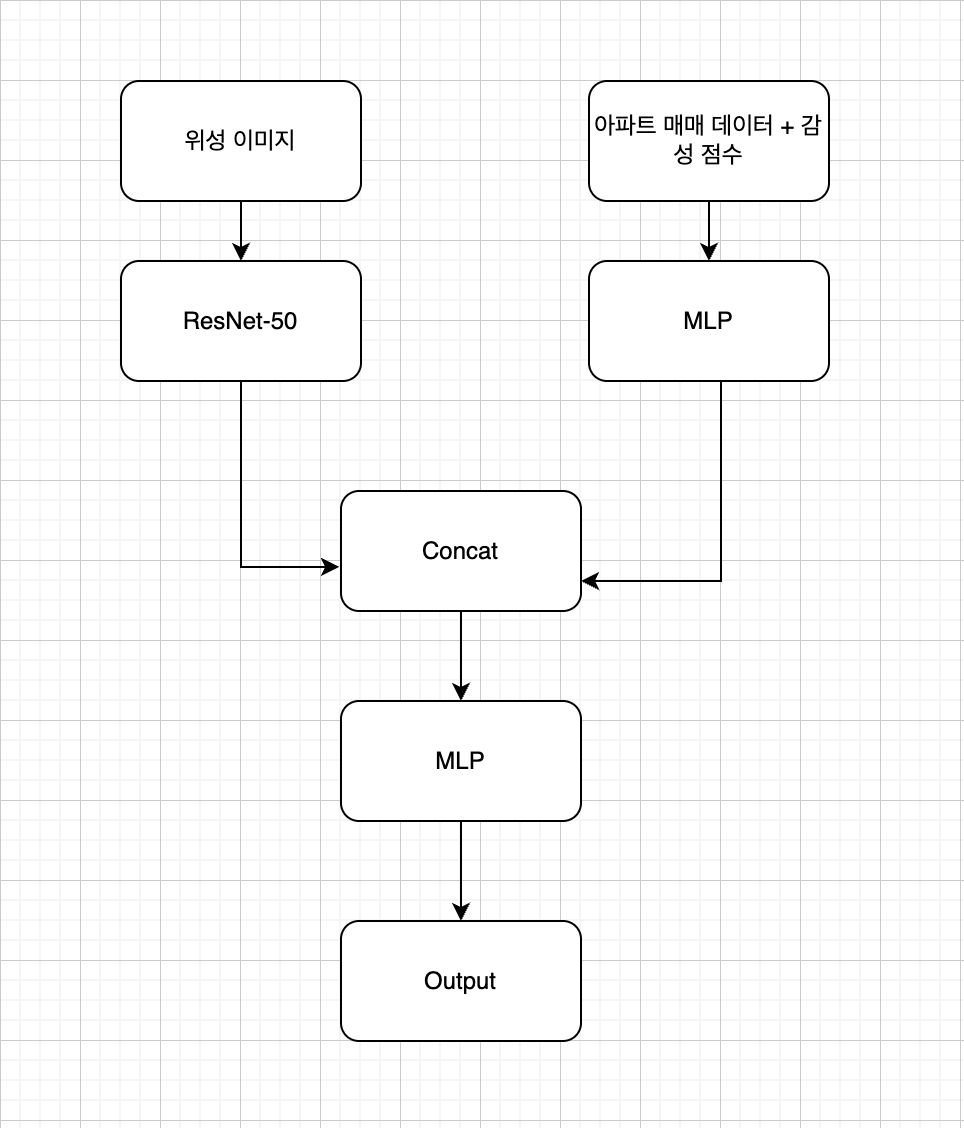

위 그림은 사용 모델의 대략적인 설계도임.

1. ResNet-50을 통해 추출한 이미지 피처를 벡터로 변환
2. 아파트 매매 + 감성 점수를 MLP 모델을 통해 벡터로 변환
3. 두 개의 벡터를 합쳐 하나의 벡터로 만듦
4. 결합된 벡터를 다시 MLP에 입력하여 예측값을 출력

- 성능 지표
    - MAE, RMSE 등등 추후에 결정 예정
 
### 실험 조건 비교
| 조합                    | 실험 목적                       |
|-------------------------|----------------------------------|
| 아파트 매매                 | 기준 성능 확인                  |
| 아파트 매매 + 이미지          | CNN 피처 기여도 확인            |
| 아파트 매매 + 감성 점수       | 감정 정보 기여도 확인           |
| 아파트 매매 + 이미지 + 감성   | 멀티모달 성능 최종 검증         |

## 최근 연구 진행 사항 요약

| 날짜   | 주요 작업                                                         |
|--------|--------------------------------------------------------------------|
| ~ 6.13 |  선행 연구 검토 및 연구 계획 수립                         |
| 6.13   | 조선일보 뉴스 6663건 수집, 결측 14건 제거, 시계열 기간 한계 확인 |
| 6.14   | 동아일보 크롤링 기능 구현, 감성 분석 전체 기사 수집 후 처리 예정 |
| 6.15   | 중앙일보, 한국경제 기사 구조 분석 및 크롤링 계획 수립             |
| 6.16   | 위성지도 미반영 요소(지하철/버스) 추가 계획 수립                 |

## 참고 논문

- 데이터 마이닝 적용을 통한 아파트 가격 예측에 관한 연구
- 기계 학습을 이용한 공동주택 가격 측정 : 서울 강남구를 사례로
- 커널밀도추정(Kernel Density Estimation)과 합성곱신경망(Convolution Neural Network)을 이용한 아파트가격 예측
- 부동산 감성지수의 주택가격 예측 유용성 : 뉴스기사와 방송뉴스 빅데이터 활용 사례
- 부동산 가격 요인과 가격상승률 요인 비교 연구 : 서울시 재건축 아파트를 중심으로